In [1]:
import numpy as np 

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"

import jax
import matplotlib.pyplot as plt

from kltpicker_3d.tomogram import KLTParticleDetector3D

#jax.config.update("jax_default_device", jax.devices("cpu")[0])

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.5
})

## Performance analyasis as function of threshold


In [2]:
N = 300
K = 200
R = 16 # True radius 
a = 2*R + 1 # Diameter of particle 
M = 2*R+1
if M % 2 == 0:
    M-=1
S = 2*M-1
tomogram = np.zeros((N,N,K),dtype=np.uint8)

rng = np.random.default_rng(0) 
flat = rng.choice(tomogram.size, size=10,replace=False)
centers = np.column_stack(np.unravel_index(flat, tomogram.shape))

dx, dy, dz = np.mgrid[-R:R+1, -R:R+1, -R:R+1]
sphere = (dx**2 + dy**2 + dz**2) <= R**2 
offsets = np.column_stack((dx[sphere], dy[sphere], dz[sphere]))

for cx, cy, cz in centers:
    pts = offsets + np.array([cx, cy, cz])         
    valid = (
        (0 <= pts[:, 0]) & (pts[:, 0] < N) &
        (0 <= pts[:, 1]) & (pts[:, 1] < N) &
        (0 <= pts[:, 2]) & (pts[:, 2] < K)
    )
    pts = pts[valid]
    tomogram[pts[:, 0], pts[:, 1], pts[:, 2]] = 1

# Bandlimiting the tomogram
# Convoluting is a distributive, so as our tomogram is a sum of sphere indicators it applies to each sphere.  
Nk = np.fft.fftfreq(N)
Kk = np.fft.fftfreq(K)

KX,KY,KZ = np.meshgrid(Nk,Nk,Kk) 
KR = np.sqrt(KX**2 + KY**2 + KZ**2)

sigma = 2
H = np.exp(-(KR / sigma)**2)
c = np.sqrt(-np.log(1e-16)*2*sigma**2)

# Convolution is distributive 
F = np.fft.fftn(tomogram)
tomogram = np.fft.ifftn(F*H).real
tomogram_clean = tomogram.copy() 
scale = 2
tomogram = tomogram + np.random.normal(scale=scale, size=tomogram.shape)

In [ ]:
detector = KLTParticleDetector3D(
    tomogram=tomogram,
    particle_diameter=a,
    mgscale=1,
    num_particles=-1,
    legendre_order=150,
    threshold=0,
    max_iter=500,
    max_order=1
)

s = tomogram_clean - tomogram_clean.mean()
P_s = np.mean(s**2)
P_n = scale**2
snr_lin = P_s / P_n
snr_lin

np.float64(0.0021851110268433205)

In [4]:
num_particles, coords = detector.process_tomogram()

/data/home/moshemaymon/.conda/envs/torch/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype int requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


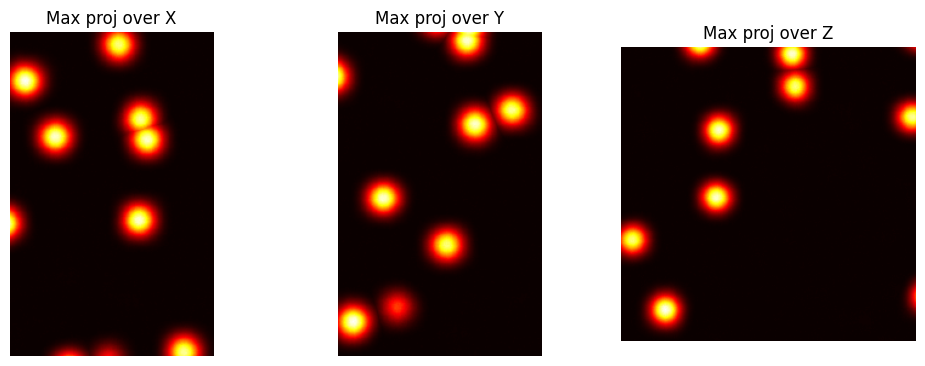

In [5]:
S = np.asarray(detector.score_mat)

fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].imshow(S.max(axis=0), cmap="hot"); ax[0].set_title("Max proj over X")
ax[1].imshow(S.max(axis=1), cmap="hot"); ax[1].set_title("Max proj over Y")
ax[2].imshow(S.max(axis=2), cmap="hot"); ax[2].set_title("Max proj over Z")
plt.tight_layout()
for a in ax: a.axis("off")
plt.show()

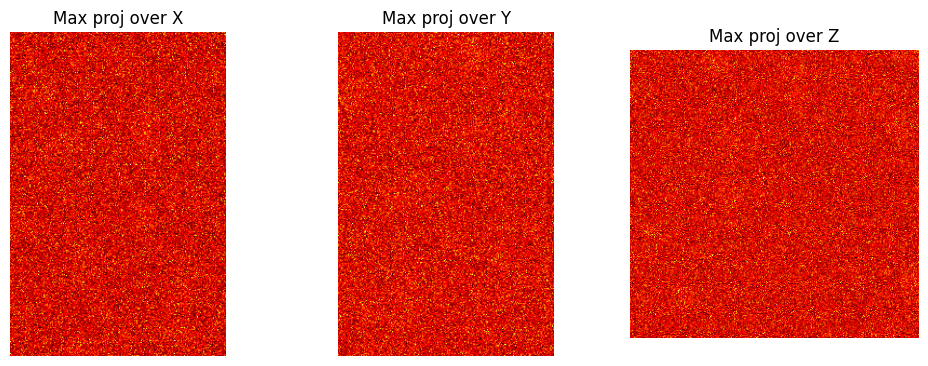

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].imshow(tomogram.max(axis=0), cmap="hot"); ax[0].set_title("Max proj over X")
ax[1].imshow(tomogram.max(axis=1), cmap="hot"); ax[1].set_title("Max proj over Y")
ax[2].imshow(tomogram.max(axis=2), cmap="hot"); ax[2].set_title("Max proj over Z")
plt.tight_layout()
for a in ax: a.axis("off")
plt.show()

In [7]:
from scipy.spatial import cKDTree

pred = np.asarray(coords)[:, :3]
gt = np.asarray(centers)

tree = cKDTree(gt)
min_dists, nn_idx = tree.query(pred, k=1)   # nearest GT center for each predicted coord

# min_dists[i] = smallest distance from coords[i] to centers
# nn_idx[i]    = index in centers of that nearest center

print("Mean min dist:", min_dists.mean())
print("Median min dist:", np.median(min_dists))
print("Max min dist:", min_dists.max())

Mean min dist: 3.6003308553196414
Median min dist: 1.5731321849709863
Max min dist: 12.68857754044952


In [8]:
min_dists

array([ 0.        ,  0.        ,  0.        ,  0.        ,  1.41421356,
        4.12310563,  5.        ,  1.73205081, 11.04536102, 12.68857754])

In [200]:
from scipy.spatial import cKDTree 

def picking_from_scoring_vol_3d(score_vol, num_particles, max_iter, 
                                threshold, template_diameter, particle_diameter):
        nx, ny, nz = score_vol.shape
        offset = template_diameter // 2 
        r_del = particle_diameter // 2
        r2 = r_del ** 2

        # Grids for spherical suppression mask
        gx = np.arange(nx)[:, None, None]
        gy = np.arange(ny)[None, :, None]
        gz = np.arange(nz)[None, None, :]

        log_max = np.max(score_vol)
        eps = 1e-12

        scoring = score_vol.copy()
        particle_list = []

        num_limit = np.inf if num_particles == -1 else int(num_particles)
        num_picked = 0

        while num_picked < min(max_iter, num_limit):
            flat_idx = np.argmax(scoring)
            p_max = scoring.flat[flat_idx]
            p_norm = p_max / (log_max + 1e-12)

            if not (p_norm > threshold):
                break

            ix, iy, iz = np.unravel_index(flat_idx, scoring.shape)

            # Convert valid-score index -> tomogram center coordinate
            cx = ix + offset
            cy = iy + offset
            cz = iz + offset

            particle_list.append([cx, cy, cz, p_max / (log_max + eps)])

            # 3D spherical NMS
            mask = (gx - ix) ** 2 + (gy - iy) ** 2 + (gz - iz) ** 2 <= r2
            scoring[mask] = -np.inf

            num_picked += 1

        particle_coords = np.array(particle_list, dtype=np.float64) if particle_list else np.zeros((0, 4))
        num_picked_particles = particle_coords.shape[0]

        return num_picked_particles, particle_coords


def eval_detection_centers(gt_centers, pred_centers, tol, pred_scores=None):
    """
    One-to-one matching with distance tolerance.
    Works when #pred != #gt.

    Args:
        gt_centers:   (Ng,3)
        pred_centers: (Np,3)
        tol:          distance tolerance (voxels)
        pred_scores:  optional (Np,) confidence scores (higher=better)

    Returns:
        dict with TP/FP/FN, precision/recall/F1, and match details.
    """
    gt = np.asarray(gt_centers, dtype=float)
    pr = np.asarray(pred_centers, dtype=float)

    Ng = gt.shape[0]
    Np = pr.shape[0]

    if Ng == 0 and Np == 0:
        return dict(TP=0, FP=0, FN=0, precision=1.0, recall=1.0, f1=1.0,
                    matched_pred_idx=np.array([], int),
                    matched_gt_idx=np.array([], int),
                    matched_dist=np.array([], float))
    if Ng == 0:
        return dict(TP=0, FP=Np, FN=0, precision=0.0, recall=1.0, f1=0.0,
                    matched_pred_idx=np.array([], int),
                    matched_gt_idx=np.array([], int),
                    matched_dist=np.array([], float))
    if Np == 0:
        return dict(TP=0, FP=0, FN=Ng, precision=1.0, recall=0.0, f1=0.0,
                    matched_pred_idx=np.array([], int),
                    matched_gt_idx=np.array([], int),
                    matched_dist=np.array([], float))

    # process predictions in descending score if provided, else original order
    if pred_scores is not None:
        order = np.argsort(np.asarray(pred_scores))[::-1]
    else:
        order = np.arange(Np)

    tree = cKDTree(gt)
    gt_used = np.zeros(Ng, dtype=bool)

    matched_pred = []
    matched_gt = []
    matched_dist = []

    for pidx in order:
        d, gidx = tree.query(pr[pidx], k=1)
        if d <= tol and not gt_used[gidx]:
            gt_used[gidx] = True
            matched_pred.append(pidx)
            matched_gt.append(gidx)
            matched_dist.append(d)

    TP = len(matched_pred)
    FP = Np - TP
    FN = Ng - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return dict(
        TP=TP, FP=FP, FN=FN,
        precision=precision, recall=recall, f1=f1,
        matched_pred_idx=np.array(matched_pred, dtype=int),
        matched_gt_idx=np.array(matched_gt, dtype=int),
        matched_dist=np.array(matched_dist, dtype=float),
    )

result = eval_detection_centers(centers, coords[:,:3], tol=13)
result

{'TP': 10,
 'FP': 0,
 'FN': 0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'matched_pred_idx': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'matched_gt_idx': array([2, 0, 9, 4, 7, 3, 5, 8, 1, 6]),
 'matched_dist': array([ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  4.12310563,  5.09901951, 11.18033989, 12.68857754])}

In [62]:
thresholds = [0,0.5,0.8,0.9]
score_mat = detector.score_mat
results = []
for threshold in thresholds:
    num_particles, coords = picking_from_scoring_vol_3d(score_mat,detector.num_particles,
                                                        detector.max_iter,threshold,
                                                        detector.template_diameter,
                                                        detector.particle_diameter)
    result = eval_detection_centers(centers, coords[:,:3],tol=4)
    results.append(result)

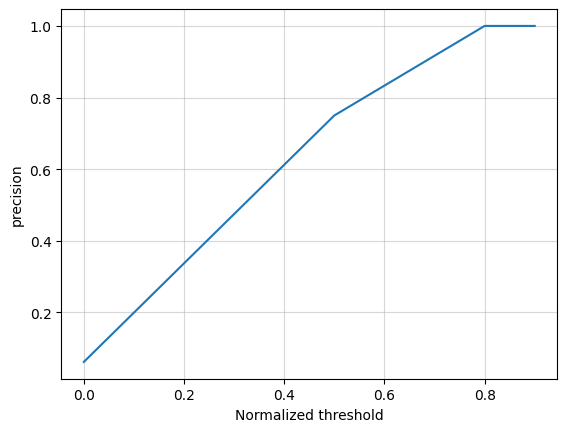

In [64]:
precision = [results[i]['precision'] for i in range(len(results))]

plt.plot(thresholds,precision)
plt.xlabel('Normalized threshold')
plt.ylabel('precision');

In [75]:
num_particles, coords = picking_from_scoring_vol_3d(score_mat,detector.num_particles,
                                                        detector.max_iter,0.5,
                                                        detector.template_diameter,
                                                        detector.particle_diameter)

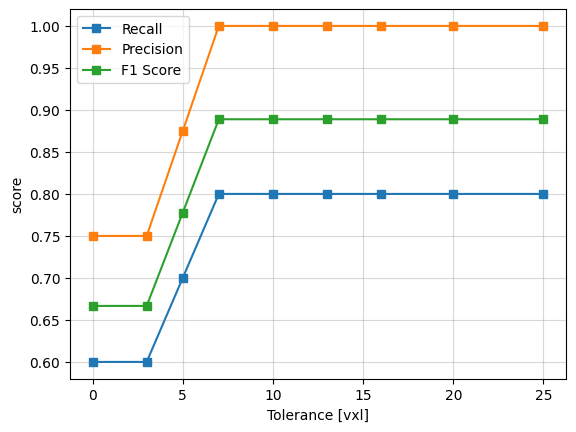

In [76]:
tolerances = np.array([0,3,5,7,10,13,16, 20, 25])
recalls = []
precisions = []
f1s = []
for tolerance in tolerances:
    result = eval_detection_centers(centers, coords[:,:3],tol=tolerance)
    recalls.append(result['recall'])
    precisions.append(result['precision'])
    f1s.append(result['f1'])

plt.plot(tolerances, recalls,'-s',label='Recall')
plt.plot(tolerances, precisions, '-s',label='Precision')
plt.plot(tolerances,f1s,'-s',label='F1 Score')
plt.legend()
plt.xlabel('Tolerance [vxl]')
plt.ylabel('score');

## Performance as function of SNR

In [106]:
scales = [0.05,0.1,0.5,1,2,5,10,15,20,25,30]
results = []
coords_l = []
for scale in scales:
    noisy_tomogram = tomogram_clean + np.random.normal(scale=scale, size=tomogram.shape)
    detector = KLTParticleDetector3D(
    tomogram=noisy_tomogram,
    particle_diameter=a,
    mgscale=1,
    bandlimit=c,
    num_particles=-1,
    legendre_order=150,
    threshold=0.5,
    max_iter=500,
    max_order=1
    )
    num_particles, coords = detector.process_tomogram()
    coords_l.append(coords)
    result = eval_detection_centers(centers, coords[:,:3],tol=4)
    results.append(result)

/data/home/moshemaymon/.conda/envs/torch/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype int requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [ ]:
scales = [0.05,0.1,0.5,1,2,5,10,15,20,25,30]
results = []
coords_l = []
for scale in scales:
    noisy_tomogram = tomogram_clean + np.random.normal(scale=scale, size=tomogram.shape)
    detector = KLTParticleDetector3D(
    tomogram=noisy_tomogram,
    particle_diameter=a,
    mgscale=1,
    bandlimit=c,
    num_particles=-1,
    legendre_order=150,
    threshold=0.5,
    max_iter=500,
    max_order=1
    )
    num_particles, coords = detector.process_tomogram()
    coords_l.append(coords)
    result = eval_detection_centers(centers, coords[:,:3],tol=4)
    results.append(result)

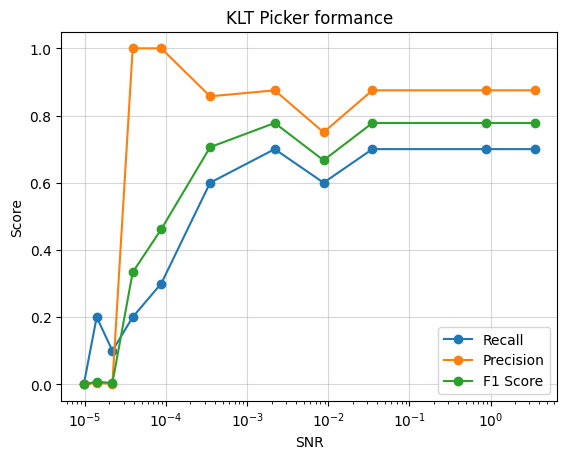

In [ ]:
s = tomogram_clean - tomogram_clean.mean()
P_s = np.mean(s**2)

snrs = []
for scale in scales:
    P_n = scale**2
    snr_lin = P_s / P_n
    snrs.append(snr_lin)
    
recalls = [result['recall'] for result in results]
precisions = [result['precision'] for result in results]
f1s = [result['f1'] for result in results]

plt.rcParams['font.family'] = 'sans-serif'


plt.plot(snrs,recalls,'-o', label='Recall')
plt.plot(snrs,precisions,'-o', label='Precision')
plt.plot(snrs,f1s,'-o', label='F1 Score')
plt.xscale('log')
plt.xlabel("SNR")
plt.ylabel('Score')
plt.title("KLT Picker formance")
plt.legend();

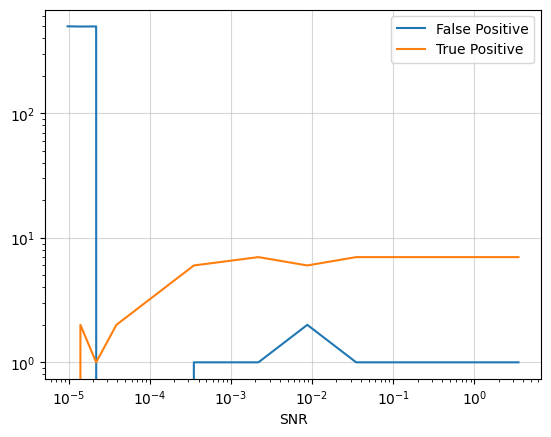

In [ ]:
fps  = [result['FP'] for result in results]
tps = [result['TP'] for result in results]
plt.plot(snrs, fps,label='False Positive')
plt.plot(snrs,tps, label='True Positive')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("SNR")
plt.legend();

This gives an explanation for the drop in precision. The constant non-maximum suppression (NMS) across the run is too small in high SNR causing one particle to be counted multiple times and as a result drop precision. 

### Performance as function of maximal $N$ order

In [ ]:
orders = [1,2,5,10]
results = []
raw_coords = []
for order in orders:
    noisy_tomogram = tomogram_clean + np.random.normal(scale=scale, size=tomogram.shape)
    detector = KLTParticleDetector3D(
    tomogram=noisy_tomogram,
    particle_diameter=a,
    mgscale=1,
    bandlimit=c,
    num_particles=-1,
    legendre_order=150,
    threshold=0.5,
    max_iter=500,
    max_order=order
    )
    num_particles, coords = detector.process_tomogram()
    raw_coords.append(coords)
    result = eval_detection_centers(centers, coords[:,:3],tol=4)
    results.append(result)

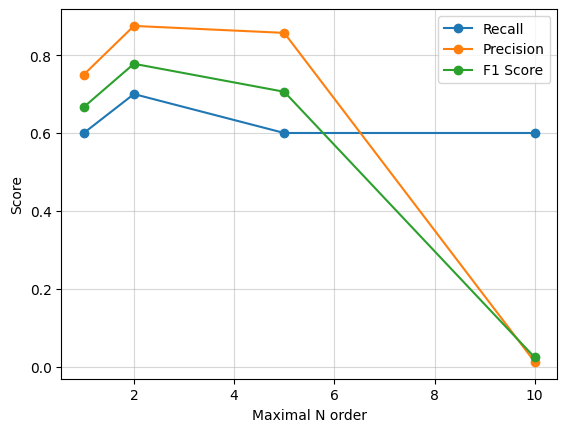

In [24]:
recalls = [result['recall'] for result in results]
precisions = [result['precision'] for result in results]
f1s = [result['f1'] for result in results]


plt.plot(orders,recalls,'-o', label='Recall')
plt.plot(orders,precisions,'-o', label='Precision')
plt.plot(orders,f1s,'-o',label='F1 Score')
plt.legend()
plt.xlabel("Maximal N order")
plt.ylabel('Score');

In [40]:
gt = np.asarray(centers)
dists = []
for i in range(len(orders)):
    pred = raw_coords[i][:,:3]
    gt = np.asarray(centers)

    tree = cKDTree(gt)
    min_dists, nn_idx = tree.query(pred, k=1)   # nearest GT center for each predicted coord
    dists.append(min_dists)

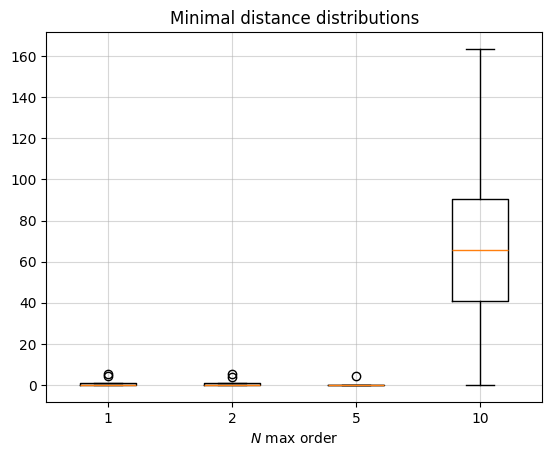

In [48]:
plt.boxplot(dists,tick_labels=orders)
plt.title("Minimal distance distributions")
plt.xlabel(r"$N$ max order");